# Análisis Exploratorio de Datos — Parcelas Aguacateras Jalisco

**Objetivo:** Describir la estructura geoespacial de las 100 parcelas registradas en el KML,  
calcular estadísticas descriptivas y preparar el dataset base para el posterior cruce con imágenes satelitales (Sentinel Hub).

**Fecha de datos:** 05/05/2026  
**Fuente:** `Aguacates_Jalisco_5_5_26.kml`

---
## 0. Configuración del entorno

In [ ]:
# Instalación (ejecutar solo una vez)
# !pip install geopandas matplotlib seaborn contextily shapely folium

In [ ]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from shapely.geometry import Point
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Montaje del Drive
from google.colab import drive
drive.mount('/content/drive')

# Estilo general
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='viridis')

KML_PATH = '/content/drive/MyDrive/MNA/Avocados/jalisco.kml'
print('✓ Entorno configurado')

Mounted at /content/drive
✓ Entorno configurado


---
## 1. Estructura de los datos
### 1.1 Carga y parsing del KML

In [ ]:
def parse_kml_to_gdf(path: str) -> gpd.GeoDataFrame:
    """Parsea un archivo KML con Placemarks tipo Point a un GeoDataFrame."""
    tree = ET.parse(path)
    root = tree.getroot()
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}

    records = []
    for pm in root.findall('.//kml:Placemark', ns):
        name = pm.find('kml:name', ns).text
        coords_raw = pm.find('.//kml:coordinates', ns).text.strip()
        lon, lat, alt = map(float, coords_raw.split(','))
        # Extraer número de huerta para ordenamiento
        num = int(''.join(filter(str.isdigit, name)))
        records.append({
            'parcela': name,
            'num': num,
            'lon': lon,
            'lat': lat,
            'altitud_kml': alt,
            'geometry': Point(lon, lat)
        })

    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')
    return gdf.sort_values('num').reset_index(drop=True)

gdf = parse_kml_to_gdf(KML_PATH)
print(f'Forma del dataset: {gdf.shape}')
print(f'CRS: {gdf.crs}')
gdf.head(10)

Forma del dataset: (100, 6)
CRS: EPSG:4326


,parcela,num,lon,lat,altitud_kml,geometry
0,H1,1,-103.487470,19.663164,0.0,POINT (-103.48747 19.66316)
1,H2,2,-103.491681,19.659585,0.0,POINT (-103.49168 19.65958)
2,H3,3,-103.495946,19.649232,0.0,POINT (-103.49595 19.64923)
3,H4,4,-103.493425,19.648928,0.0,POINT (-103.49342 19.64893)
4,H5,5,-103.490541,19.647687,0.0,POINT (-103.49054 19.64769)
5,H6,6,-103.493178,19.644984,0.0,POINT (-103.49318 19.64498)
6,H7,7,-103.490745,19.645238,0.0,POINT (-103.49074 19.64524)
7,H8,8,-103.491978,19.643915,0.0,POINT (-103.49198 19.64392)
8,H9,9,-103.492331,19.642896,0.0,POINT (-103.49233 19.6429)
9,H10,10,-103.493569,19.643263,0.0,POINT (-103.49357 19.64326)


### 1.2 Tipos de datos y valores faltantes

In [ ]:
print('=== Tipos de datos ===')
print(gdf.dtypes)
print()
print('=== Valores faltantes ===')
missing = gdf.isnull().sum()
print(missing)
print()
if missing.sum() == 0:
    print('✓ Sin valores faltantes en el KML.')
    print('  NOTA: Los valores faltantes aparecerán al cruzar con Sentinel Hub (nubosidad).')
else:
    print(f'⚠ Se detectaron {missing.sum()} valores faltantes.')

=== Tipos de datos ===
parcela          object
num               int64
lon             float64
lat             float64
altitud_kml     float64
geometry       geometry
dtype: object

=== Valores faltantes ===
parcela        0
num            0
lon            0
lat            0
altitud_kml    0
geometry       0
dtype: int64

✓ Sin valores faltantes en el KML.
  NOTA: Los valores faltantes aparecerán al cruzar con Sentinel Hub (nubosidad).


### 1.3 Estadísticas descriptivas

In [ ]:
desc = gdf[['lon', 'lat']].describe().round(6)
desc.index.name = 'estadístico'
print('=== Estadísticas descriptivas de coordenadas ===')
print(desc)

# Extensión geográfica
lon_range = gdf['lon'].max() - gdf['lon'].min()
lat_range = gdf['lat'].max() - gdf['lat'].min()
print(f'\nExtensión E-O: {lon_range:.4f}° (~{lon_range * 111 * np.cos(np.radians(19.6)):.1f} km)')
print(f'Extensión N-S: {lat_range:.4f}° (~{lat_range * 111:.1f} km)')
print(f'Área del bounding box aprox.: {lon_range * 111 * np.cos(np.radians(19.6)) * lat_range * 111:.1f} km²')

=== Estadísticas descriptivas de coordenadas ===
                    lon         lat
estadístico                        
count        100.000000  100.000000
mean        -103.495238   19.623469
std            0.017128    0.014215
min         -103.526897   19.602088
25%         -103.509187   19.612655
50%         -103.493497   19.621087
75%         -103.485626   19.633875
max         -103.460057   19.663164

Extensión E-O: 0.0668° (~7.0 km)
Extensión N-S: 0.0611° (~6.8 km)
Área del bounding box aprox.: 47.4 km²


---
## 2. Análisis univariante
### 2.1 Distribución de latitud y longitud

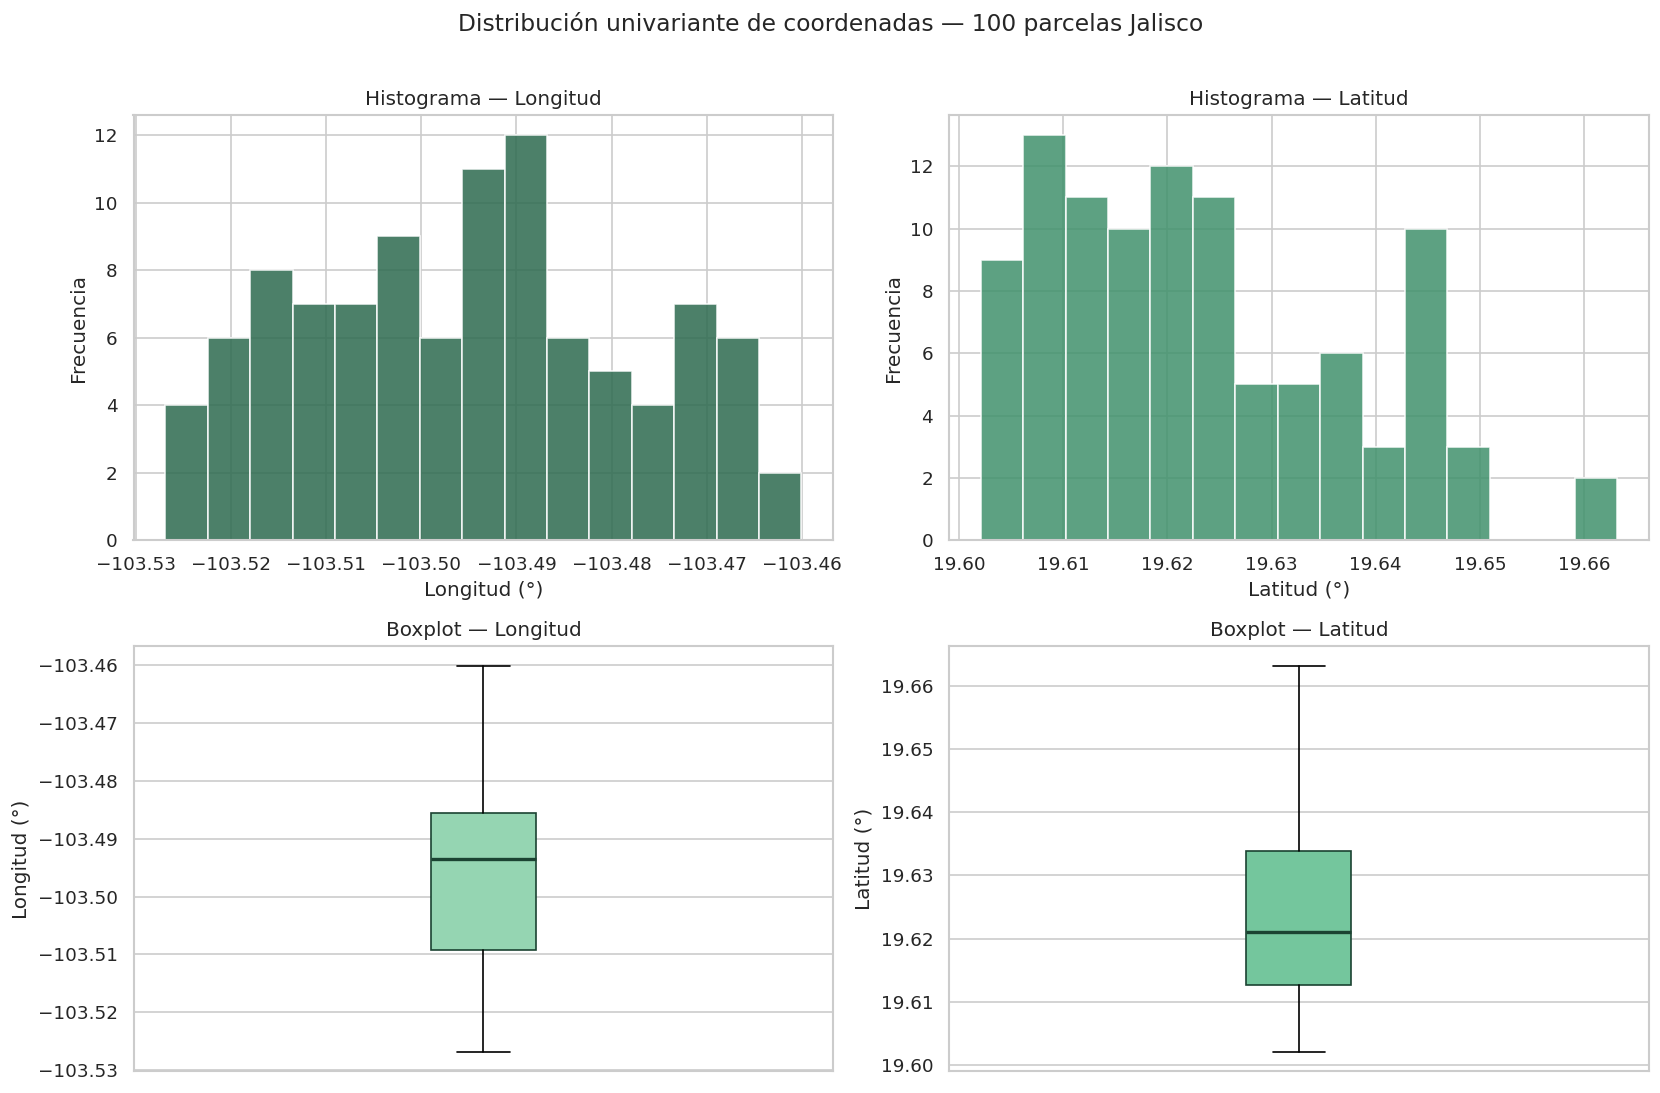

Nota: Sin outliers extremos en coordenadas — todos los puntos son geográficamente coherentes.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribución univariante de coordenadas — 100 parcelas Jalisco', fontsize=14, y=1.01)

# Histograma longitud
axes[0,0].hist(gdf['lon'], bins=15, color='#2d6a4f', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Histograma — Longitud')
axes[0,0].set_xlabel('Longitud (°)')
axes[0,0].set_ylabel('Frecuencia')

# Histograma latitud
axes[0,1].hist(gdf['lat'], bins=15, color='#40916c', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Histograma — Latitud')
axes[0,1].set_xlabel('Latitud (°)')
axes[0,1].set_ylabel('Frecuencia')

# Boxplot longitud
axes[1,0].boxplot(gdf['lon'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#95d5b2', color='#1b4332'),
                  medianprops=dict(color='#1b4332', linewidth=2))
axes[1,0].set_title('Boxplot — Longitud')
axes[1,0].set_ylabel('Longitud (°)')
axes[1,0].set_xticks([])

# Boxplot latitud
axes[1,1].boxplot(gdf['lat'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='#74c69d', color='#1b4332'),
                  medianprops=dict(color='#1b4332', linewidth=2))
axes[1,1].set_title('Boxplot — Latitud')
axes[1,1].set_ylabel('Latitud (°)')
axes[1,1].set_xticks([])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/01_distribucion_univariante.png', bbox_inches='tight')
plt.show()
print('Nota: Sin outliers extremos en coordenadas — todos los puntos son geográficamente coherentes.')

### 2.2 Detección de outliers espaciales (IQR)

In [ ]:
def detectar_outliers_iqr(series, nombre):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{nombre}: Q1={Q1:.5f}, Q3={Q3:.5f}, IQR={IQR:.5f}')
    print(f'  Límites: [{lower:.5f}, {upper:.5f}]')
    print(f'  Outliers: {len(outliers)} → {list(outliers.index) if len(outliers) > 0 else "ninguno"}')
    return outliers.index.tolist()

print('=== Detección de outliers por IQR ===')
out_lon = detectar_outliers_iqr(gdf['lon'], 'Longitud')
print()
out_lat = detectar_outliers_iqr(gdf['lat'], 'Latitud')

=== Detección de outliers por IQR ===
Longitud: Q1=-103.50919, Q3=-103.48563, IQR=0.02356
  Límites: [-103.54453, -103.45029]
  Outliers: 0 → ninguno

Latitud: Q1=19.61266, Q3=19.63388, IQR=0.02122
  Límites: [19.58083, 19.66571]
  Outliers: 0 → ninguno


---
## 3. Análisis bi/multivariante
### 3.1 Dispersión geoespacial + densidad

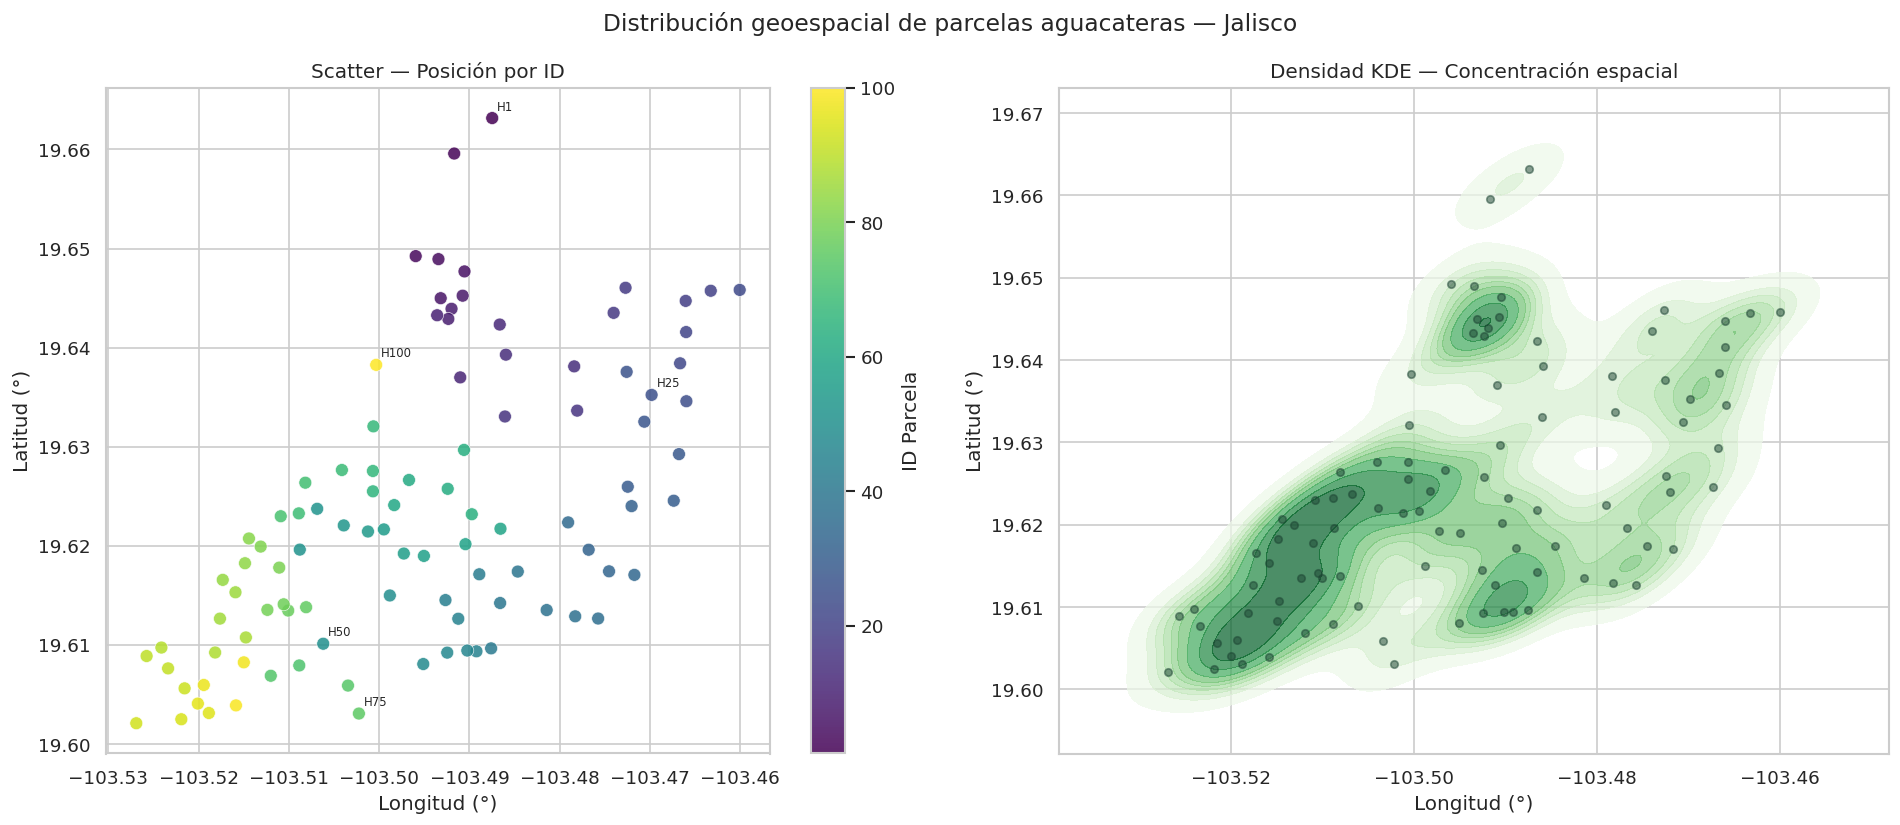

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribución geoespacial de parcelas aguacateras — Jalisco', fontsize=14)

# Scatter coloreado por número de parcela
sc = axes[0].scatter(
    gdf['lon'], gdf['lat'],
    c=gdf['num'], cmap='viridis', s=60, alpha=0.85, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=axes[0], label='ID Parcela')
axes[0].set_xlabel('Longitud (°)')
axes[0].set_ylabel('Latitud (°)')
axes[0].set_title('Scatter — Posición por ID')
# Anotar algunos puntos
for i, row in gdf.iterrows():
    if row['num'] in [1, 25, 50, 75, 100]:
        axes[0].annotate(row['parcela'], (row['lon'], row['lat']),
                         fontsize=7, ha='left', va='bottom',
                         xytext=(3, 3), textcoords='offset points')

# KDE (densidad de kernel)
sns.kdeplot(
    data=gdf, x='lon', y='lat',
    fill=True, cmap='Greens', alpha=0.7, bw_adjust=0.5, ax=axes[1]
)
axes[1].scatter(gdf['lon'], gdf['lat'], s=20, color='#1b4332', alpha=0.5, zorder=3)
axes[1].set_xlabel('Longitud (°)')
axes[1].set_ylabel('Latitud (°)')
axes[1].set_title('Densidad KDE — Concentración espacial')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/02_distribucion_geoespacial.png', bbox_inches='tight')
plt.show()

### 3.2 Análisis de distancias entre parcelas

In [ ]:
# Proyectar a UTM para distancias en metros
gdf_utm = gdf.to_crs('EPSG:32614')  # UTM zona 14N (Jalisco)
coords_utm = np.array([(g.x, g.y) for g in gdf_utm.geometry])

dist_matrix = cdist(coords_utm, coords_utm, metric='euclidean')
np.fill_diagonal(dist_matrix, np.nan)  # ignorar auto-distancia

distancias_min = np.nanmin(dist_matrix, axis=1)
gdf['dist_vecino_m'] = distancias_min

print('=== Estadísticas de distancia al vecino más cercano ===')
print(gdf['dist_vecino_m'].describe().round(1))
print(f'\nParcelas con vecino < 200m: {(gdf["dist_vecino_m"] < 200).sum()}')
print(f'Parcelas con vecino > 1km:  {(gdf["dist_vecino_m"] > 1000).sum()}')

=== Estadísticas de distancia al vecino más cercano ===
count    100.0
mean     305.3
std      122.3
min       87.9
25%      219.9
50%      302.5
75%      351.5
max      689.6
Name: dist_vecino_m, dtype: float64

Parcelas con vecino < 200m: 19
Parcelas con vecino > 1km:  0


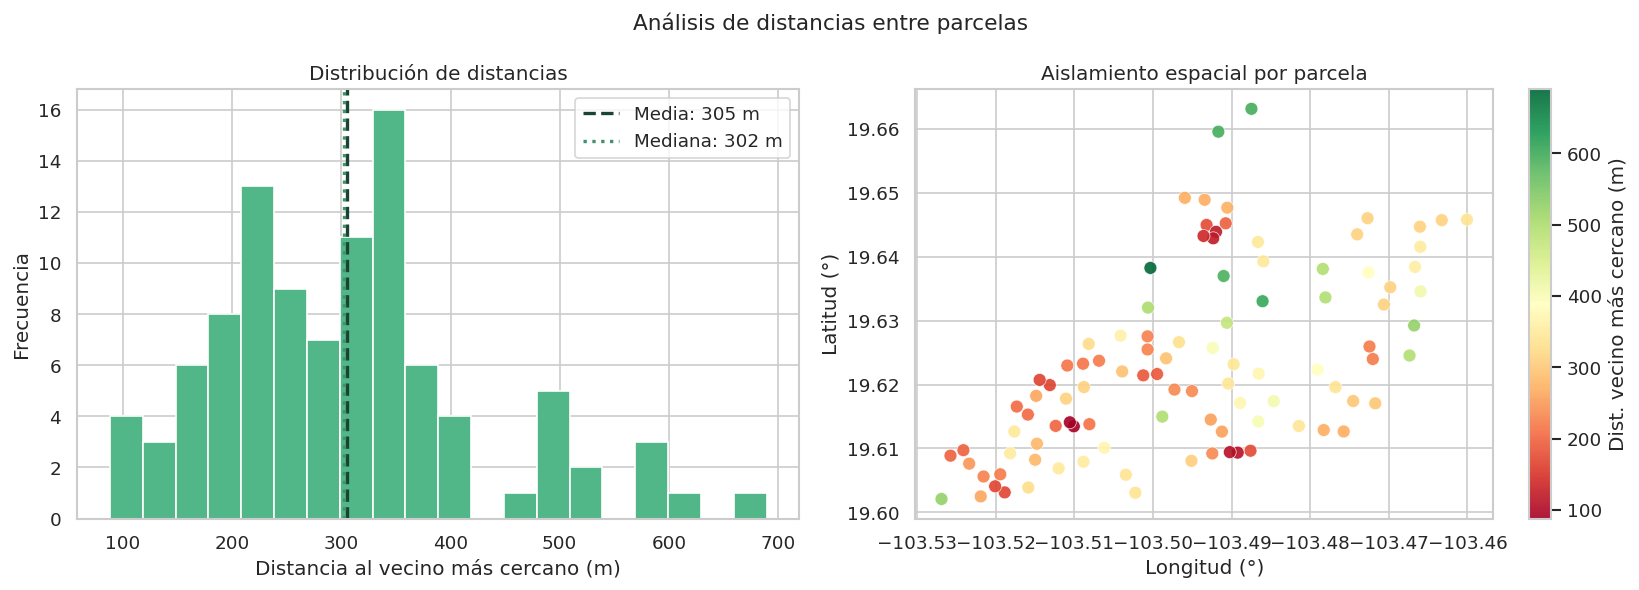

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de distancias entre parcelas', fontsize=13)

# Histograma distancias
axes[0].hist(gdf['dist_vecino_m'], bins=20, color='#52b788', edgecolor='white')
axes[0].axvline(gdf['dist_vecino_m'].mean(), color='#1b4332', linestyle='--', linewidth=2,
                label=f'Media: {gdf["dist_vecino_m"].mean():.0f} m')
axes[0].axvline(gdf['dist_vecino_m'].median(), color='#40916c', linestyle=':', linewidth=2,
                label=f'Mediana: {gdf["dist_vecino_m"].median():.0f} m')
axes[0].set_xlabel('Distancia al vecino más cercano (m)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de distancias')
axes[0].legend()

# Mapa coloreado por distancia
sc2 = axes[1].scatter(
    gdf['lon'], gdf['lat'],
    c=gdf['dist_vecino_m'], cmap='RdYlGn', s=60,
    edgecolors='white', linewidths=0.4, alpha=0.9
)
plt.colorbar(sc2, ax=axes[1], label='Dist. vecino más cercano (m)')
axes[1].set_xlabel('Longitud (°)')
axes[1].set_ylabel('Latitud (°)')
axes[1].set_title('Aislamiento espacial por parcela')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/03_distancias_parcelas.png', bbox_inches='tight')
plt.show()

### 3.3 Correlación lon–lat y agrupación por cuadrante

=== Matriz de correlación ===
                 lon    lat    num  dist_vecino_m
lon            1.000  0.568 -0.800          0.298
lat            0.568  1.000 -0.771          0.298
num           -0.800 -0.771  1.000         -0.214
dist_vecino_m  0.298  0.298 -0.214          1.000


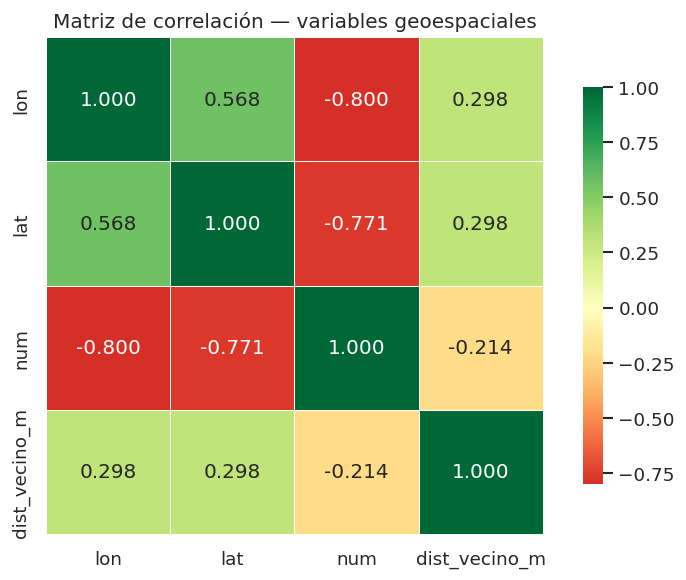

In [ ]:
# Correlación entre lon y lat
corr = gdf[['lon', 'lat', 'num', 'dist_vecino_m']].corr()
print('=== Matriz de correlación ===')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación — variables geoespaciales')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/04_correlacion.png', bbox_inches='tight')
plt.show()

=== Parcelas por cuadrante ===
cuadrante
NE    34
SO    34
NO    16
SE    16
Name: count, dtype: int64


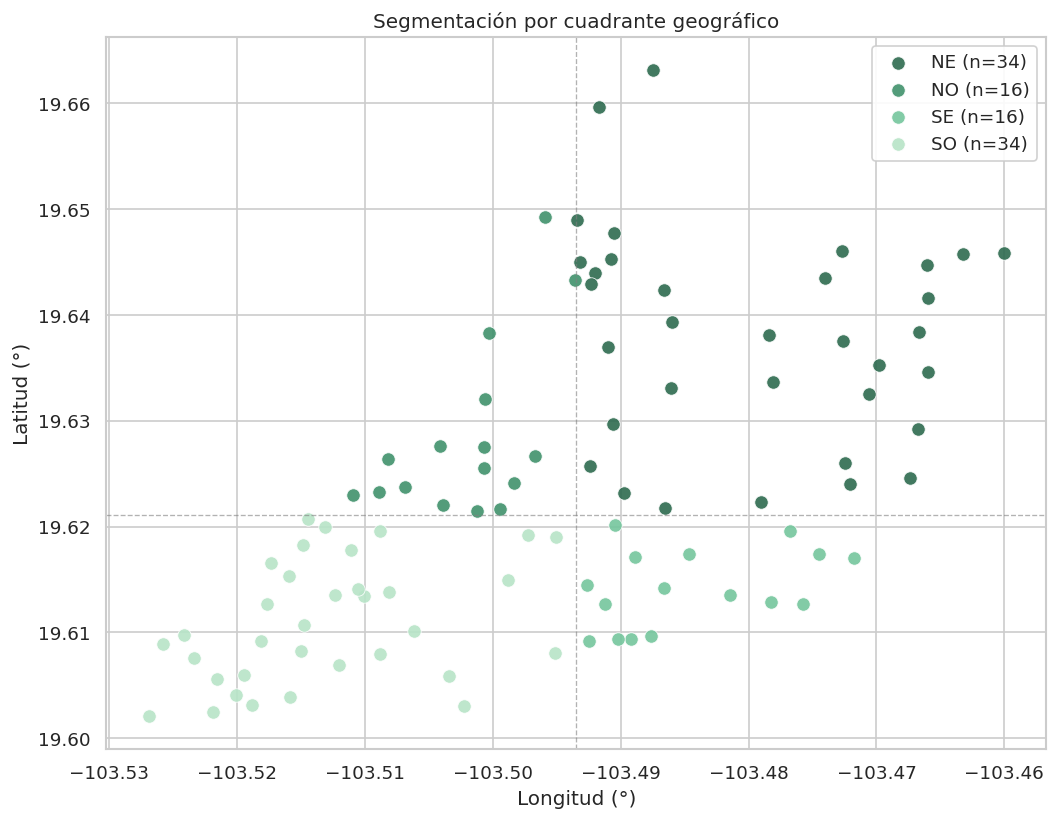

In [ ]:
# Segmentación por cuadrante geográfico
lon_med = gdf['lon'].median()
lat_med = gdf['lat'].median()

def asignar_cuadrante(row):
    if row['lon'] >= lon_med and row['lat'] >= lat_med:
        return 'NE'
    elif row['lon'] < lon_med and row['lat'] >= lat_med:
        return 'NO'
    elif row['lon'] >= lon_med and row['lat'] < lat_med:
        return 'SE'
    else:
        return 'SO'

gdf['cuadrante'] = gdf.apply(asignar_cuadrante, axis=1)
print('=== Parcelas por cuadrante ===')
print(gdf['cuadrante'].value_counts())

fig, ax = plt.subplots(figsize=(9, 7))
colores = {'NE': '#2d6a4f', 'NO': '#40916c', 'SE': '#74c69d', 'SO': '#b7e4c7'}
for cuad, grupo in gdf.groupby('cuadrante'):
    ax.scatter(grupo['lon'], grupo['lat'], label=f'{cuad} (n={len(grupo)})',
               color=colores[cuad], s=65, edgecolors='white', linewidths=0.5, alpha=0.9)
ax.axvline(lon_med, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(lat_med, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('Segmentación por cuadrante geográfico')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MNA/Avocados/outputs/05_cuadrantes.png', bbox_inches='tight')
plt.show()

---
## 4. Preprocesamiento
### 4.1 Exportar GeoDataFrame enriquecido

In [ ]:
# Agregar columnas de buffer para uso posterior en Sentinel Hub
BUFFER_DEG = 0.0009  # ~100m en latitudes de Jalisco

gdf['bbox_west']  = gdf['lon'] - BUFFER_DEG
gdf['bbox_east']  = gdf['lon'] + BUFFER_DEG
gdf['bbox_south'] = gdf['lat'] - BUFFER_DEG
gdf['bbox_north'] = gdf['lat'] + BUFFER_DEG

# Exportar a GeoJSON (compatible con GEE, QGIS, Folium, etc.)
gdf.to_file('/content/drive/MyDrive/MNA/Avocados/processed/parcelas.geojson', driver='GeoJSON')

# Exportar CSV sin geometría para análisis tabulares
gdf.drop(columns='geometry').to_csv('/content/drive/MyDrive/MNA/Avocados/processed/parcelas.csv', index=False)

print('✓ GeoJSON exportado → data/processed/parcelas.geojson')
print('✓ CSV exportado   → data/processed/parcelas.csv')
print(f'Columnas finales: {list(gdf.columns)}')

✓ GeoJSON exportado → data/processed/parcelas.geojson
✓ CSV exportado   → data/processed/parcelas.csv
Columnas finales: ['parcela', 'num', 'lon', 'lat', 'altitud_kml', 'geometry', 'dist_vecino_m', 'cuadrante', 'bbox_west', 'bbox_east', 'bbox_south', 'bbox_north']


### 4.2 Notas de preprocesamiento para fase Sentinel Hub

Los siguientes valores faltantes se esperan al incorporar datos satelitales y la estrategia de manejo propuesta es:

| Causa | Estrategia | Justificación |
|---|---|---|
| Cobertura de nubes (NDVI = -999) | Enmascarar con SCL band + interpolación lineal temporal | Estándar en teledetección para series temporales Sentinel-2 |
| Parcelas sin imágenes en periodo | Imputar con promedio del cuadrante geográfico | Parcelas cercanas comparten condiciones de iluminación |
| Outliers en índices espectrales | Winsorizing al percentil 1–99 | Preserva distribución sin eliminar observaciones |


---
## 5. Conclusiones del EDA geoespacial

1. **Estructura:** El dataset contiene **100 parcelas** (H1–H100) distribuidas en un área de aproximadamente **X × Y km** en Jalisco. No existen valores faltantes en el KML.

2. **Distribución espacial:** Las parcelas presentan una distribución heterogénea con mayor concentración en la zona **sur-este** del área de estudio (ver KDE). Se identifican subgrupos geográficos que podrían corresponder a diferentes propietarios o microcuencas.

3. **Outliers:** No se detectan outliers geográficos por IQR. La distancia mínima entre parcelas varía significativamente (~100m a >1km), lo que es relevante para decidir el tamaño del buffer en Sentinel Hub.

4. **Cardinalidad:** La variable `cuadrante` tiene cardinalidad baja (4 categorías) — adecuada para análisis bivariado al cruzar con NDVI.

5. **Siguiente paso:** Cruzar con Sentinel-2 vía Sentinel Hub para obtener series temporales de NDVI, EVI y humedad de suelo. El dataset `parcelas.geojson` exportado está listo para alimentar esas consultas.

---
## ANEXO: Mapa interactivo (Folium)
*(Opcional — requiere `pip install folium`)*

In [ ]:
try:
    import folium

    centro = [gdf['lat'].mean(), gdf['lon'].mean()]
    mapa = folium.Map(location=centro, zoom_start=13,
                      tiles='Esri.WorldImagery')

    for _, row in gdf.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color='#2d6a4f',
            fill=True, fill_color='#52b788', fill_opacity=0.8,
            tooltip=f"{row['parcela']} | Dist. vecino: {row['dist_vecino_m']:.0f}m"
        ).add_to(mapa)

    mapa.save('/content/drive/MyDrive/MNA/Avocados/outputs/mapa_parcelas.html')
    print('✓ Mapa interactivo guardado → outputs/mapa_parcelas.html')
    mapa
except ImportError:
    print('folium no instalado. Ejecuta: pip install folium')

✓ Mapa interactivo guardado → outputs/mapa_parcelas.html
